In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# note from ref2: Transport related features of molecules MW, MLOGP, vapor preassure, boiling point, alpha area, 
and five descriptors most correlated with Hill coefficients (CATS2D_03_LL, SpMax8_Bh.p., MPC07, MATS7i, H2s).

## Goal
The goal of this notebook is to set up a features set for the intensity basic classification model.

According to the domain knowledge follwinf chemico-physical features should be related to the smell intensity

### Mass
- **f1** = `{MW}` (Molecular Weight)

### Lipophilicity
- **f2** = `{MLOGP}`
- **f3** = `{ALOGP, ALOGP2, MLOGP, MLOGP2}`

### Volume (van der Waals volume)
- **f4** = `VvdwMG`
- **f5** = `VvdwZAZ`
- **f6** = `Sv` (sum of atomic volumes)

### Surface area and shape
- **f7** = `{Morxxu, Morxxm, Morxxv, ...}` - Derived from electron diffraction; encodes 3D atom distribution and relates to molecular shape and boiling point.
- **f8** = `{RDFxxxx...}` - Probability of finding atoms at specific distances; captures molecular size, surface spread, and compactness.
- **f9** = `{L1, L2u, L3u, Tu, Au, ...}` - WHIM descriptors based on 3D coordinates; encode molecular shape, symmetry, and surface anisotropy.
- **f10** = `{HATS*, R*}` - Combines geometry and topology; encodes how atoms are distributed over molecular surface.
- **f11** = `{GATS*}` - Spatial autocorrelation descriptors; captures how properties vary across molecular surface.

### Polarity
- **f12** = `{PDI}` - Higher values indicate stronger interactions and often lower vapor pressure.

### Surface-related descriptors for vapor pressure
- **f13** = `{P_VSA_LogP_2, P_VSA_LogP_3, P_VSA_LogP_4, P_VSA_LogP_5, P_VSA_LogP_7}` - Partitioned van der Waals surface area; captures surface area and polarity distribution.

### Shape/size distribution related to vapor pressure
- **f14** = `{SpDiam_A, SpDiam_D, SpDiam_L, SpDiam_X}`


In [30]:
data_df = pd.read_csv('data/waka_dragon_merged.csv')

In [31]:
data_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [32]:
data_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'CID', 'CAS', 'Name', 'Imax', 'Ci',
       'Di_x', 'intensity_class', 'MW',
       ...
       'VvdwMG', 'VvdwZAZ', 'PDI', 'BLTF96', 'BLTD48', 'BLTA96', 'nCIR', 'ZM1',
       'R8u_', 'nRCOSR'],
      dtype='str', length=2499)

In [33]:
# Count how many descriptors from each defined feature group exist in data_df
columns = list(data_df.columns)
column_lookup = {c.lower(): c for c in columns}

feature_groups = {
    "f1_mass": {
        "exact": ["MW"],
        "prefix": [],
    },
    "f2_lipophilicity": {
        "exact": ["MLOGP"],
        "prefix": [],
    },
    "f3_lipophilicity_extended": {
        "exact": ["ALOGP", "ALOGP2", "MLOGP", "MLOGP2"],
        "prefix": [],
    },
    "f4_volume": {
        "exact": ["VvdwMG"],
        "prefix": [],
    },
    "f5_volume": {
        "exact": ["VvdwZAZ"],
        "prefix": [],
    },
    "f6_volume": {
        "exact": ["Sv"],
        "prefix": [],
    },
    "f7_surface_shape_Mor": {
        "exact": ["Morxxu", "Morxxm", "Morxxv"],
        "prefix": ["Mor"],
    },
    "f8_surface_shape_RDF": {
        "exact": ["RDFxxxx"],
        "prefix": ["RDF"],
    },
    "f9_whim": {
        "exact": ["L1", "L2u", "L3u", "Tu", "Au"],
        "prefix": [],
    },
    "f10_geometry_topology": {
        "exact": [],
        "prefix": ["HATS", "R"],
    },
    "f11_spatial_autocorrelation": {
        "exact": [],
        "prefix": ["GATS"],
    },
    "f12_polarity": {
        "exact": ["PDI"],
        "prefix": [],
    },
    "f13_p_vsa_logp": {
        "exact": [
            "P_VSA_LogP_2",
            "P_VSA_LogP_3",
            "P_VSA_LogP_4",
            "P_VSA_LogP_5",
            "P_VSA_LogP_7",
        ],
        "prefix": [],
    },
    "f14_spdiam": {
        "exact": ["SpDiam_A", "SpDiam_D", "SpDiam_L", "SpDiam_X"],
        "prefix": [],
    },
}


def match_exact(names):
    return [column_lookup[n.lower()] for n in names if n.lower() in column_lookup]


def match_prefix(prefixes):
    if not prefixes:
        return []
    matches = []
    for c in columns:
        c_lower = c.lower()
        if any(c_lower.startswith(p.lower()) for p in prefixes):
            matches.append(c)
    return matches


rows = []
for group_name, cfg in feature_groups.items():
    exact_names = cfg["exact"]
    prefixes = cfg["prefix"]

    exact_found = match_exact(exact_names)
    prefix_found = match_prefix(prefixes)

    found_all = sorted(set(exact_found + prefix_found))
    missing_exact = [n for n in exact_names if n.lower() not in column_lookup]

    rows.append(
        {
            "group": group_name,
            "defined_exact": len(exact_names),
            "found_exact": len(exact_found),
            "found_by_prefix": len(prefix_found),
            "total_found": len(found_all),
            "missing_exact": missing_exact,
            "example_found": found_all[:8],
            "columns_found": found_all,
        }
    )

# Keep output in the same order as groups are defined above (f1 -> f14)
summary_df = pd.DataFrame(rows).reset_index(drop=True)
# group_name -> full list of data_df column names in that group (for dimension reduction)
group_columns = summary_df.set_index("group")["columns_found"].to_dict()
# Compact table: full lists are in summary_df["columns_found"] and group_columns
summary_df[
    [
        "group",
        "defined_exact",
        "found_exact",
        "found_by_prefix",
        "total_found",
        "missing_exact",
        "example_found",
    ]
]

,group,defined_exact,found_exact,found_by_prefix,total_found,missing_exact,example_found
0,f1_mass,1,1,0,1,[],[MW]
1,f2_lipophilicity,1,1,0,1,[],[MLOGP]
2,f3_lipophilicity_extended,4,4,0,4,[],"[ALOGP, ALOGP2, MLOGP, MLOGP2]"
3,f4_volume,1,1,0,1,[],[VvdwMG]
4,f5_volume,1,1,0,1,[],[VvdwZAZ]
5,f6_volume,1,1,0,1,[],[Sv]
6,f7_surface_shape_Mor,3,0,223,223,"[Morxxu, Morxxm, Morxxv]","[Mor01e, Mor01i, Mor01m, Mor01p, Mor01s, Mor01..."
7,f8_surface_shape_RDF,1,0,209,209,[RDFxxxx],"[RDF010e, RDF010i, RDF010m, RDF010p, RDF010s, ..."
8,f9_whim,5,4,0,4,[L1],"[Au, L2u, L3u, Tu]"
9,f10_geometry_topology,0,0,390,390,[],"[HATS0e, HATS0i, HATS0m, HATS0p, HATS0s, HATS0..."


In [34]:
# Target number of dimensions per feature group after reduction (e.g. PCA n_components).
# Run after the cell that defines `group_columns`. Tune high-D groups as you explore.
feat_dict = {
    "f1_mass": 1,
    "f2_lipophilicity": 1,
    "f3_lipophilicity_extended": 4,
    "f4_volume": 1,
    "f5_volume": 1,
    "f6_volume": 1,
    "f7_surface_shape_Mor": 7,
    "f8_surface_shape_RDF": 8,
    "f9_whim": 4,
    "f10_geometry_topology": 8,
    "f11_spatial_autocorrelation": 8,
    "f12_polarity": 1,
    "f13_p_vsa_logp": 5,
    "f14_spdiam": 4,
}

assert set(feat_dict) == set(group_columns), "feat_dict keys must match group_columns"
feat_dict

{'f1_mass': 1,
 'f2_lipophilicity': 1,
 'f3_lipophilicity_extended': 4,
 'f4_volume': 1,
 'f5_volume': 1,
 'f6_volume': 1,
 'f7_surface_shape_Mor': 7,
 'f8_surface_shape_RDF': 8,
 'f9_whim': 4,
 'f10_geometry_topology': 8,
 'f11_spatial_autocorrelation': 8,
 'f12_polarity': 1,
 'f13_p_vsa_logp': 5,
 'f14_spdiam': 4}

In [35]:
print(f'The type of group_columns varibale is {type(group_columns)}') # for every feature group it defines the list of founf features
group_columns

The type of group_columns varibale is <class 'dict'>


{'f1_mass': ['MW'],
 'f2_lipophilicity': ['MLOGP'],
 'f3_lipophilicity_extended': ['ALOGP', 'ALOGP2', 'MLOGP', 'MLOGP2'],
 'f4_volume': ['VvdwMG'],
 'f5_volume': ['VvdwZAZ'],
 'f6_volume': ['Sv'],
 'f7_surface_shape_Mor': ['Mor01e',
  'Mor01i',
  'Mor01m',
  'Mor01p',
  'Mor01s',
  'Mor01v',
  'Mor02e',
  'Mor02i',
  'Mor02m',
  'Mor02p',
  'Mor02s',
  'Mor02u',
  'Mor02v',
  'Mor03e',
  'Mor03i',
  'Mor03m',
  'Mor03p',
  'Mor03s',
  'Mor03u',
  'Mor03v',
  'Mor04e',
  'Mor04i',
  'Mor04m',
  'Mor04p',
  'Mor04s',
  'Mor04u',
  'Mor04v',
  'Mor05e',
  'Mor05i',
  'Mor05m',
  'Mor05p',
  'Mor05s',
  'Mor05u',
  'Mor05v',
  'Mor06e',
  'Mor06i',
  'Mor06m',
  'Mor06p',
  'Mor06s',
  'Mor06u',
  'Mor06v',
  'Mor07e',
  'Mor07i',
  'Mor07m',
  'Mor07p',
  'Mor07s',
  'Mor07u',
  'Mor07v',
  'Mor08e',
  'Mor08i',
  'Mor08m',
  'Mor08p',
  'Mor08s',
  'Mor08u',
  'Mor08v',
  'Mor09e',
  'Mor09i',
  'Mor09m',
  'Mor09p',
  'Mor09s',
  'Mor09u',
  'Mor09v',
  'Mor10e',
  'Mor10i',
  'Mor10m',

In [36]:
summary_df.columns

Index(['group', 'defined_exact', 'found_exact', 'found_by_prefix',
       'total_found', 'missing_exact', 'example_found', 'columns_found'],
      dtype='str')

In [37]:
group_columns

{'f1_mass': ['MW'],
 'f2_lipophilicity': ['MLOGP'],
 'f3_lipophilicity_extended': ['ALOGP', 'ALOGP2', 'MLOGP', 'MLOGP2'],
 'f4_volume': ['VvdwMG'],
 'f5_volume': ['VvdwZAZ'],
 'f6_volume': ['Sv'],
 'f7_surface_shape_Mor': ['Mor01e',
  'Mor01i',
  'Mor01m',
  'Mor01p',
  'Mor01s',
  'Mor01v',
  'Mor02e',
  'Mor02i',
  'Mor02m',
  'Mor02p',
  'Mor02s',
  'Mor02u',
  'Mor02v',
  'Mor03e',
  'Mor03i',
  'Mor03m',
  'Mor03p',
  'Mor03s',
  'Mor03u',
  'Mor03v',
  'Mor04e',
  'Mor04i',
  'Mor04m',
  'Mor04p',
  'Mor04s',
  'Mor04u',
  'Mor04v',
  'Mor05e',
  'Mor05i',
  'Mor05m',
  'Mor05p',
  'Mor05s',
  'Mor05u',
  'Mor05v',
  'Mor06e',
  'Mor06i',
  'Mor06m',
  'Mor06p',
  'Mor06s',
  'Mor06u',
  'Mor06v',
  'Mor07e',
  'Mor07i',
  'Mor07m',
  'Mor07p',
  'Mor07s',
  'Mor07u',
  'Mor07v',
  'Mor08e',
  'Mor08i',
  'Mor08m',
  'Mor08p',
  'Mor08s',
  'Mor08u',
  'Mor08v',
  'Mor09e',
  'Mor09i',
  'Mor09m',
  'Mor09p',
  'Mor09s',
  'Mor09u',
  'Mor09v',
  'Mor10e',
  'Mor10i',
  'Mor10m',

In [38]:
from ml_feature_matrix import build_ml_feature_matrix, raw_features_slice

In [39]:
features_df = raw_features_slice(data_df)  # data_df.loc[:, "MW":]
X_ml = build_ml_feature_matrix(features_df, feat_dict)
# Keep molecule id aligned with labels / external tables (same index as data_df)
X_ml = pd.concat([data_df[["CID"]], X_ml], axis=1)

In [40]:
X_ml.columns

Index(['CID', 'f1_mass_PC1', 'f2_lipophilicity_PC1',
       'f3_lipophilicity_extended_PC1', 'f3_lipophilicity_extended_PC2',
       'f3_lipophilicity_extended_PC3', 'f3_lipophilicity_extended_PC4',
       'f4_volume_PC1', 'f5_volume_PC1', 'f6_volume_PC1',
       'f7_surface_shape_Mor_PC1', 'f7_surface_shape_Mor_PC2',
       'f7_surface_shape_Mor_PC3', 'f7_surface_shape_Mor_PC4',
       'f7_surface_shape_Mor_PC5', 'f7_surface_shape_Mor_PC6',
       'f7_surface_shape_Mor_PC7', 'f8_surface_shape_RDF_PC1',
       'f8_surface_shape_RDF_PC2', 'f8_surface_shape_RDF_PC3',
       'f8_surface_shape_RDF_PC4', 'f8_surface_shape_RDF_PC5',
       'f8_surface_shape_RDF_PC6', 'f8_surface_shape_RDF_PC7',
       'f8_surface_shape_RDF_PC8', 'f9_whim_PC1', 'f9_whim_PC2', 'f9_whim_PC3',
       'f9_whim_PC4', 'f10_geometry_topology_PC1', 'f10_geometry_topology_PC2',
       'f10_geometry_topology_PC3', 'f10_geometry_topology_PC4',
       'f10_geometry_topology_PC5', 'f10_geometry_topology_PC6',
       'f10_

(array([13., 27., 29., 66., 82., 48., 24., 13.,  8.,  2.]),
 array([-2.26729582, -1.72415888, -1.18102194, -0.637885  , -0.09474805,
         0.44838889,  0.99152583,  1.53466277,  2.07779971,  2.62093665,
         3.16407359]),
 <BarContainer object of 10 artists>)

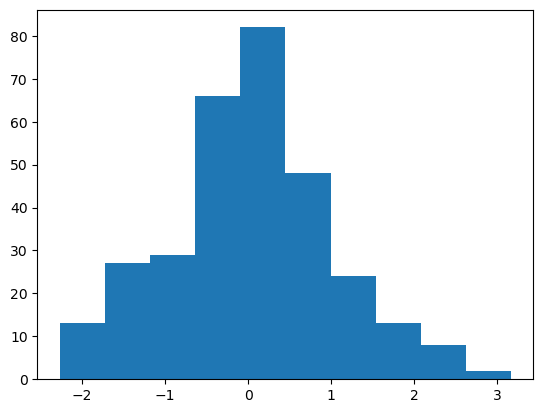

In [43]:
plt.hist(X_ml["f5_volume_PC1"])  # first column is CID; pick features by name

In [42]:
X_ml.to_csv('data/features_df_v1.csv')